# Speeding up the training process

After investigating how to train a flow to replicate the LHCb IP distribution in `notebooks/flow_to_lhcb_ip_sim.ipynb`, and then learning how to extract the transformation from a flow and make composite flows, I was then able to construct a data->simulation flow.

At the beginning of this notebook (commit d11c4f679df2150c0d89aabd7e70b346c1818ab1) the training of this flow (with `scripts/ip_correction_flow.py`) takes around 5 minutes, with an observed *slow-down* when naively porting the training to the GPU. 

In this notebook I want to investigate if I can make this faster. This is important because:
1. 5 minutes is ~5x slower than the non-ML "classical" IP correction model that I currently use, and would be a speed bottleneck in a physics analysis workflow
2. When assessing uncertainties, it may be that we need to run many different versions of this training. The time cost is therefore multiplied.

Currently we have a model that feels relatively simple: it is 2 1D spline transformations. I feel therefore that 5 minutes of training is a bit expensive for the task here, and experience suggests that there will be low-hanging fruit in terms of speeding up a new workflow.

### Ideas/avenues for exploration
* Complexity of the flow: it *looks* fairly simple. Is it actually simple under-the-hood? Am I giving many layers, parameters etc that are just unrequired?
* Hardware acceleration: Naive translation to GPU didn't speed things up. Are we actually multi-threading the training?
* Training iterations and sample size: do we need 100k events and 10k iterations of training to achieve the current performance? How does it scale with iterations and numbers of events?

Let's first look into the complexity of the flow.

In [3]:
from nflows import transforms, flows, distributions
import torch
import uproot
import numpy as np

In [4]:
def make_1d_quad_flow() -> tuple[transforms.Transform, flows.Flow]:
    N_FEATURES = 1
    transform = transforms.PiecewiseRationalQuadraticCDF(
        shape=N_FEATURES, tails="linear", tail_bound=4, num_bins=3
    )
    return transform, flows.Flow(
        transform=transform,
        distribution=distributions.StandardNormal(shape=[N_FEATURES]),
    )

Checking out the definition of `PiecewiseRationalQuadraticCDF` [here](https://github.com/bayesiains/nflows/blob/master/nflows/transforms/nonlinearities.py), we get 1 `nn.Parameter` for "width" and "height" which is initialised by a tensor of shape [1, nbins] in my case, which should mean 2 d.o.f for each "bin". I set up with 3 bins. Then also get `nbins - 1` parameters for derivatives. Each `nn.Parameter` is initialised tracking its gradients too. 

The `forward` method of the transformation just calls `_spline` on the inputs - this should be just acting our 1D tensor of scalar IP values. It takes the batch size as `inputs.shape[0]`, so would that be 1 or the number of samples? Let's check:

In [9]:
def load_data(sample_type: str, n_samples: int) -> torch.Tensor:
    # Load up the simulated data and put it into a 1D numpy array
    file = uproot.open(f"../data/tuple_for_training__{sample_type}.root")
    muon_prefix = "mup_"  # could also use mum_
    branch = f"{muon_prefix}IP"
    selection = "(1>0)"
    ip_arr = (
        file["DecayTree"]
        .arrays(branch, cut=selection, library="np")[branch]
        .astype(np.float64)
    )

    # take first n_samples from sim_log10_ip
    log10_ip_arr = np.log10(ip_arr)[:, :n_samples]

    # Reshape needed to swap the axes to match what the flow expects
    log10_ip_arr = torch.tensor(log10_ip_arr, dtype=torch.float32).reshape(-1, 1)
    return log10_ip_arr

In [10]:
import matplotlib.pyplot as plt

In [11]:
def plot_from_sample(samples: torch.Tensor) -> None:
    _, ax = plt.subplots()
    hist, bins = np.histogram(samples, bins=100, range=(-4, 0))
    ax.bar(x=bins[:-1], height=hist, yerr=np.sqrt(hist), width=bins[1] - bins[0])
    ax.set_xlabel("log10(IP / mm)")
    ax.set_ylabel("Candidates / bin")
    plt.show()

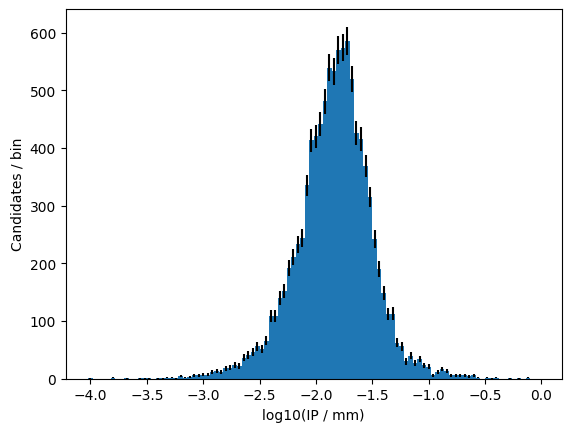

In [12]:
target_sample = load_data("Z", 10000)
plot_from_sample(target_sample)

In [14]:
# got my data, what's the shape?
print(target_sample.shape)
print(target_sample.shape[0])

torch.Size([10000, 1])
10000


So it seems that I'll end up with a batch size of 10000. The batch size means how many values of the data sample are passed through `forward` each iteration, so indeed if we don't bother using the GPU then the simplest thing to do is to act on all the data. However, I'll probably have too high a requirement on a GPU's memory to work with my entire sample every iteration. This is probably a strong driver on the GPU performance.

If the first dimension of my data was batch size (would need to ensure this), then I might get a speedup with the GPU.

**TODO: check out the issue list for discussion of this point**
Done: found nothing.

Everything is then passed into `splines.unconstrained_rational_quadratic_spline` giving back an output tensor (presumably the transformed vector of values) and `logabsdet` - I'll guess a `NSAMPLES`-long vector of log(abs(determinants)) which are then summed up. 

`unconstrained_rational_quadratic_spline` is defined [here](https://github.com/bayesiains/nflows/blob/master/nflows/transforms/splines/rational_quadratic.py). Immediately I see that really it is made for a distribution centred about 0, and so our tail bounds are being placed about [-4, 4]. We could shift the IP to align. `logabsdet` is indeed same shape as input. 

I notice now that I am not providing a `min_bin_width`, a `min_bin_height` or a `min_derivative`. These all default to 1e-3, so v. small. Wonder if that is important or not. I *think* height and width are here all referring to Figure 1 in the [Neural Spline Flows](https://papers.nips.cc/paper_files/paper/2019/file/7ac71d433f282034e088473244df8c02-Paper.pdf) paper, which is describing the transformation as a x->y type mapping, so width is relevant on the x axis and height is relevant on the y axis. 

All-in-all, this just goes and does the work of the flow. We can't go in and optimise that.

There's nothing in the issues about speeding the things up.

So, ideas from this:
* Could try to reduce the range from [-4, 4] to [-2, 2] if I move it up, or even a window that is 3 wide
* Could set a min bin width of e.g. 0.1 or 0.5 as that should be enough to describe the rate of variation. I'd probably say something similar on the bin height
* Could try a bit harder batching the data to try and achieve a speedup.

In [16]:
# Let's try a bit harder on batching the data
batch_size = 64
target_sample_dl = torch.utils.data.DataLoader(
    target_sample, batch_size=batch_size, shuffle=False
)
print(len(target_sample_dl))
for i_batch, batch in enumerate(target_sample_dl):
    print(i_batch, batch.shape)
    if i_batch > 3:
        break


157
0 torch.Size([64, 1])
1 torch.Size([64, 1])
2 torch.Size([64, 1])
3 torch.Size([64, 1])
4 torch.Size([64, 1])


Indeed, for 10k events and a batch size of 64, we get 10k /ceiling divide/ 64 = 157 batches. And indeed, looping over this, `batch.shape[0]` would indeed be the batch size as we might expect.

In our existing `train_flow` code, we do the following:
```python
       if batch_the_data:
            loss = 0
            for batch in target_data_dl:
                optimizer.zero_grad()
                batch_loss = -flow.log_prob(inputs=batch).mean()
                loss += batch_loss
                batch_loss.backward()
                optimizer.step()
```
However, I we have a single optimizer with 1 set of parameters, and we're zeroing the gradients *every batch* and stepping the optimizer every batch. And doing `loss.backward`. Do we really want to do that? I think the point would be to end up calling the `forward` method on the batch (I guess `flow.log_prob` does that), and probs doing the `backward` step indeed needs to happen to every batch, but the rest I think can happen once per major iteration, not once per batch iteration.

Let's try this.


In [17]:
def train_flow_benchmark(
    flow: flows.Flow,
    target_data: torch.Tensor,
    n_iter: int,
    xrange=(-4, 0),
    batch_size=64,
    use_gpu=False,
    batch_the_data=False,
) -> None:
    # Train the flow, and periodically plot the results
    # Batching the data for 100k events with 1 input feature is slower than not batching, but it was interesting to add the functionality.
    binning = dict(bins=100, range=xrange)

    # Setup the plot
    _, ax = plt.subplots(2, 3, figsize=(15, 10))
    ax = ax.flatten()
    hist_target, bins = np.histogram(target_data, **binning)
    i_fig = 0

    # Put everything on the GPU if it is available and desired
    device = "cuda" if (torch.cuda.is_available() and use_gpu) else "cpu"
    print(f"INFO:\tUsing device: {device}")
    flow = flow.to(device)
    target_data = target_data.to(device)
    if batch_the_data:
        target_data_dl = torch.utils.data.DataLoader(
            target_data, batch_size=batch_size, shuffle=False
        )

    optimizer = torch.optim.Adam(flow.parameters())
    for i in range(n_iter + 1):

        if batch_the_data:
            loss = 0
            optimizer.zero_grad()
            for batch in target_data_dl:
                batch_loss = -flow.log_prob(inputs=batch).mean()
                loss += batch_loss
                batch_loss.backward()
            optimizer.step()
        else:
            optimizer.zero_grad()
            loss = -flow.log_prob(inputs=target_data).mean()
            loss.backward()
            optimizer.step()

        if i % (n_iter / 5) != 0:
            continue

        with torch.inference_mode():
            print(f"Loss at iteration {i}: {loss}")
            ax[i_fig].set_title(f"Iteration {i}: Loss = {loss:.5f}")
            ax[i_fig].bar(
                x=bins[:-1],
                height=hist_target,
                yerr=np.sqrt(hist_target),
                width=bins[1] - bins[0],
                label="MC",
                fill=False,
                edgecolor="blue",
            )
            ax[i_fig].set_xlabel("log10(IP / mm)")
            ax[i_fig].set_ylabel("Candidates / bin")

            # Sample from the flow and plot the histogram
            samples = flow.sample(target_data.shape[0])
            pred_hist, bins = np.histogram(
                samples.cpu(), **binning
            )  # move to cpu for plotting
            ax[i_fig].bar(
                x=bins[:-1],
                height=pred_hist,
                yerr=np.sqrt(pred_hist),
                width=bins[1] - bins[0],
                label="Flow",
                fill=False,
                edgecolor="red",
            )

            ax[i_fig].legend()
            i_fig += 1

    plt.show()

    # Put everything back on the CPU for plotting etc. downstream
    target_data.cpu()
    flow.cpu()

INFO:	Using device: cuda
Loss at iteration 0: 47.5865592956543
Loss at iteration 20: 43.52909851074219
Loss at iteration 40: 39.56108474731445
Loss at iteration 60: 35.73991775512695
Loss at iteration 80: 32.124568939208984
Loss at iteration 100: 28.771854400634766


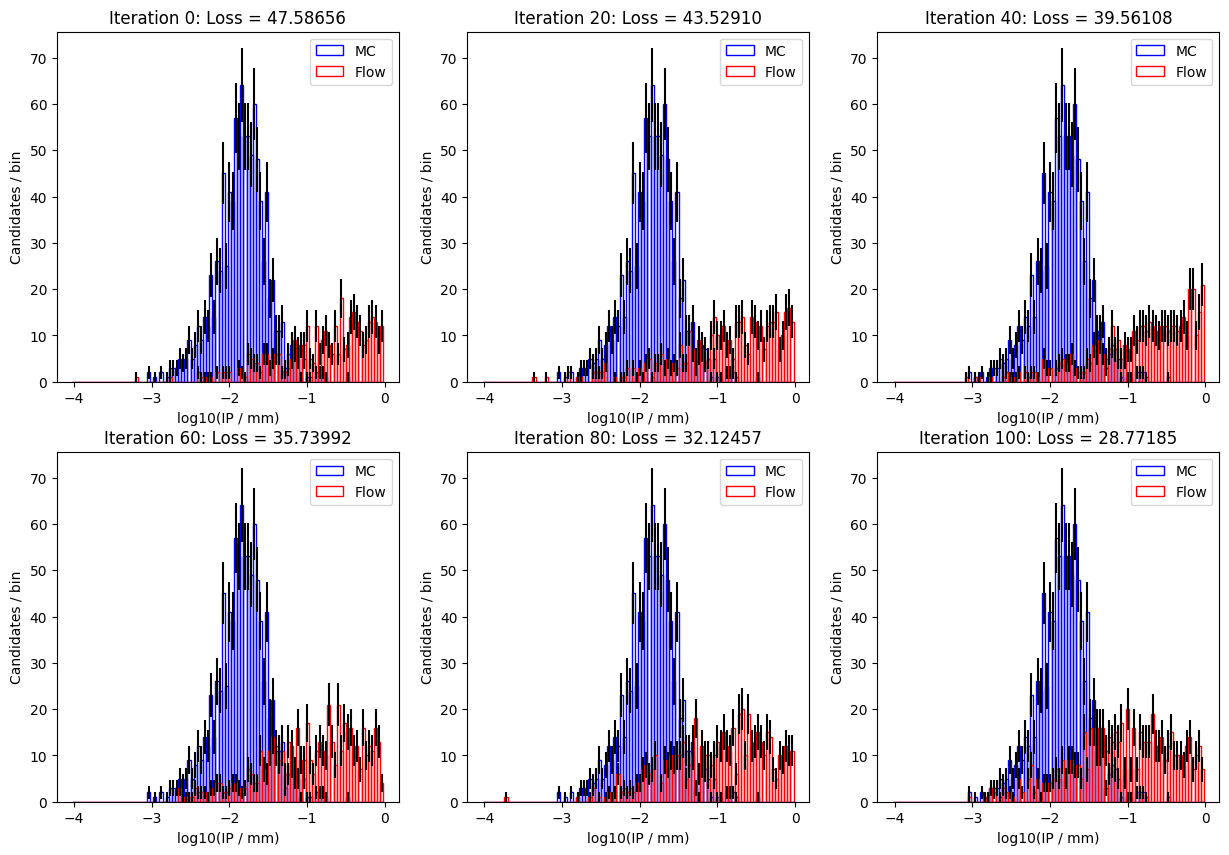

Execution time: 8.570339441299438 seconds
INFO:	Using device: cuda
Loss at iteration 0: 4.552902698516846
Loss at iteration 20: 4.270859718322754
Loss at iteration 40: 3.9916512966156006
Loss at iteration 60: 3.718742847442627
Loss at iteration 80: 3.4559648036956787
Loss at iteration 100: 3.206839084625244


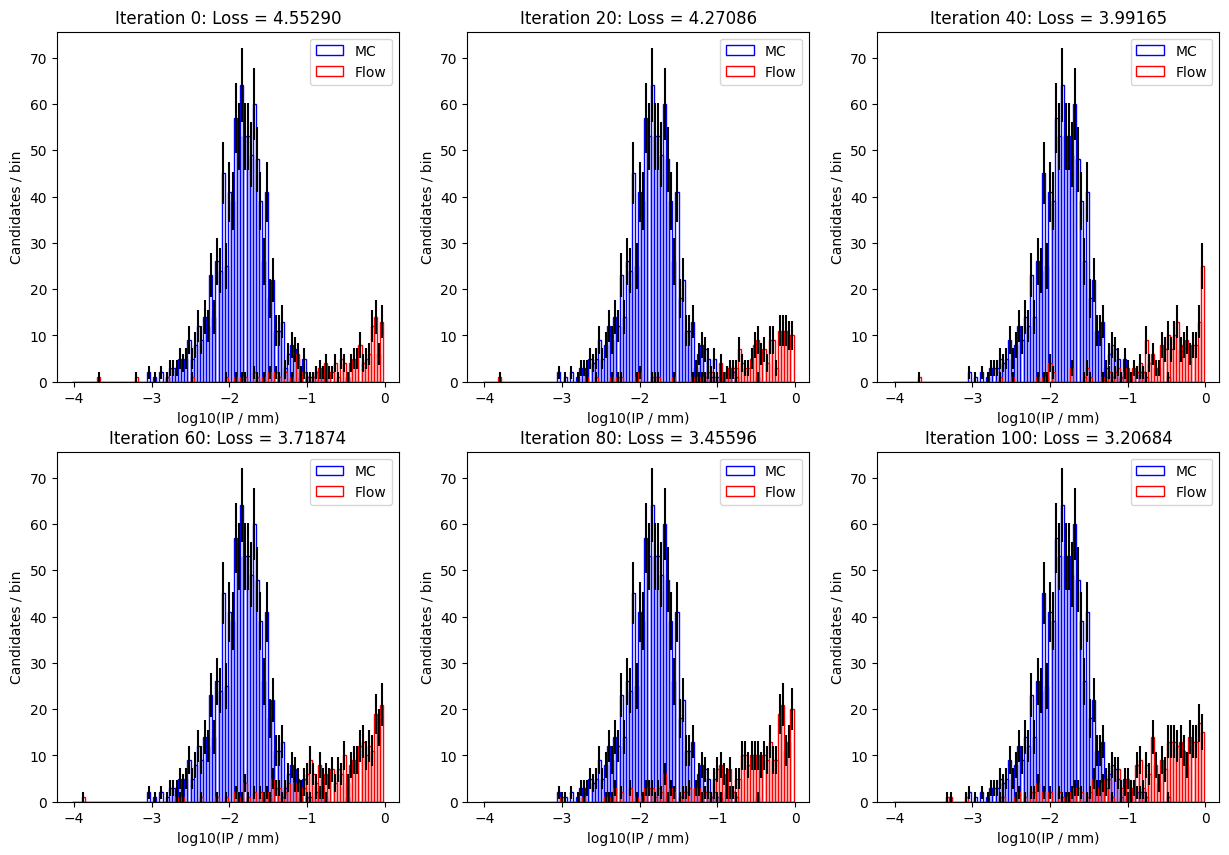

Execution time: 2.4292709827423096 seconds


In [23]:
import time

target_sample = load_data("Z", 1000)
for batch_the_data in (True, False):
    torch.manual_seed(42)
    start_time = time.time()
    quad_transform, quad_flow = make_1d_quad_flow()
    train_flow_benchmark(quad_flow, target_sample, 100, use_gpu=True, batch_the_data=batch_the_data)
    end_time = time.time()

    execution_time = end_time - start_time
    print(f"Execution time: {execution_time} seconds")

So, even at this stage, if in both cases we're on the GPU I get a big slowdown *with* the batching. This makes me suspect that my batches are on the CPU... can check this  

In [24]:
# Let's try a bit harder on batching the data
target_sample = load_data("Z", 10000)
batch_size = 64
target_sample_dl = torch.utils.data.DataLoader(
    target_sample, batch_size=batch_size, shuffle=False
)
print(len(target_sample_dl))
for i_batch, batch in enumerate(target_sample_dl):
    print(i_batch, batch.shape, batch.device)
    if i_batch > 3:
        break


157
0 torch.Size([64, 1]) cpu
1 torch.Size([64, 1]) cpu
2 torch.Size([64, 1]) cpu
3 torch.Size([64, 1]) cpu
4 torch.Size([64, 1]) cpu


A-ha! Well yes that'll slow me down. OK, re-write that part of the function and re-benchmark

In [42]:
def train_flow_hopefully_faster(
    flow: flows.Flow,
    target_data: torch.Tensor,
    n_iter: int,
    xrange=(-4, 0),
    batch_size=64,
    use_gpu=False,
    batch_the_data=False,
) -> None:
    # Train the flow, and periodically plot the results
    # Batching the data for 100k events with 1 input feature is slower than not batching, but it was interesting to add the functionality.
    binning = dict(bins=100, range=xrange)

    # Setup the plot
    _, ax = plt.subplots(2, 3, figsize=(15, 10))
    ax = ax.flatten()
    hist_target, bins = np.histogram(target_data, **binning)
    i_fig = 0

    # Put everything on the GPU if it is available and desired
    device = "cuda" if (torch.cuda.is_available() and use_gpu) else "cpu"
    print(f"INFO:\tUsing device: {device}")
    flow = flow.to(device)
    target_data = target_data.to(device)
    print(f"Target data is on device: {target_data.device}")
    if batch_the_data:
        # Using pin_memory = True here didnt ork: got "cannot pin 'torch.cuda.FloatTensor' only dense CPU tensors can be pinned"
        target_data_dl = torch.utils.data.DataLoader(
            target_data, batch_size=batch_size, shuffle=False
        )
        for i_batch, batch in enumerate(target_data_dl):
            if i_batch < 2:
                print(i_batch, batch.shape, batch.device)
            # batch = batch.to(device)

    optimizer = torch.optim.Adam(flow.parameters())
    for i in range(n_iter + 1):

        if batch_the_data:
            loss = 0
            for batch in target_data_dl:
                optimizer.zero_grad()
                batch_loss = -flow.log_prob(inputs=batch).mean()
                loss += batch_loss.item()
                batch_loss.backward()
                optimizer.step()
        else:
            optimizer.zero_grad()
            loss = -flow.log_prob(inputs=target_data).mean()
            loss.backward()
            optimizer.step()

        if i % (n_iter / 5) != 0:
            continue

        with torch.inference_mode():
            print(f"Loss at iteration {i}: {loss}")
            ax[i_fig].set_title(f"Iteration {i}: Loss = {loss:.5f}")
            ax[i_fig].bar(
                x=bins[:-1],
                height=hist_target,
                yerr=np.sqrt(hist_target),
                width=bins[1] - bins[0],
                label="MC",
                fill=False,
                edgecolor="blue",
            )
            ax[i_fig].set_xlabel("log10(IP / mm)")
            ax[i_fig].set_ylabel("Candidates / bin")

            # Sample from the flow and plot the histogram
            samples = flow.sample(target_data.shape[0])
            pred_hist, bins = np.histogram(
                samples.cpu(), **binning
            )  # move to cpu for plotting
            ax[i_fig].bar(
                x=bins[:-1],
                height=pred_hist,
                yerr=np.sqrt(pred_hist),
                width=bins[1] - bins[0],
                label="Flow",
                fill=False,
                edgecolor="red",
            )

            ax[i_fig].legend()
            i_fig += 1

    plt.show()

    # Put everything back on the CPU for plotting etc. downstream
    target_data.cpu()
    flow.cpu()

INFO:	Using device: cuda
Target data is on device: cuda:0
0 torch.Size([64, 1]) cuda:0
1 torch.Size([64, 1]) cuda:0
Loss at iteration 0: 26.93633544445038
Loss at iteration 20: 11.623937726020813
Loss at iteration 40: 9.142316281795502
Loss at iteration 60: 8.021092653274536
Loss at iteration 80: 7.4148015677928925
Loss at iteration 100: 7.037897616624832


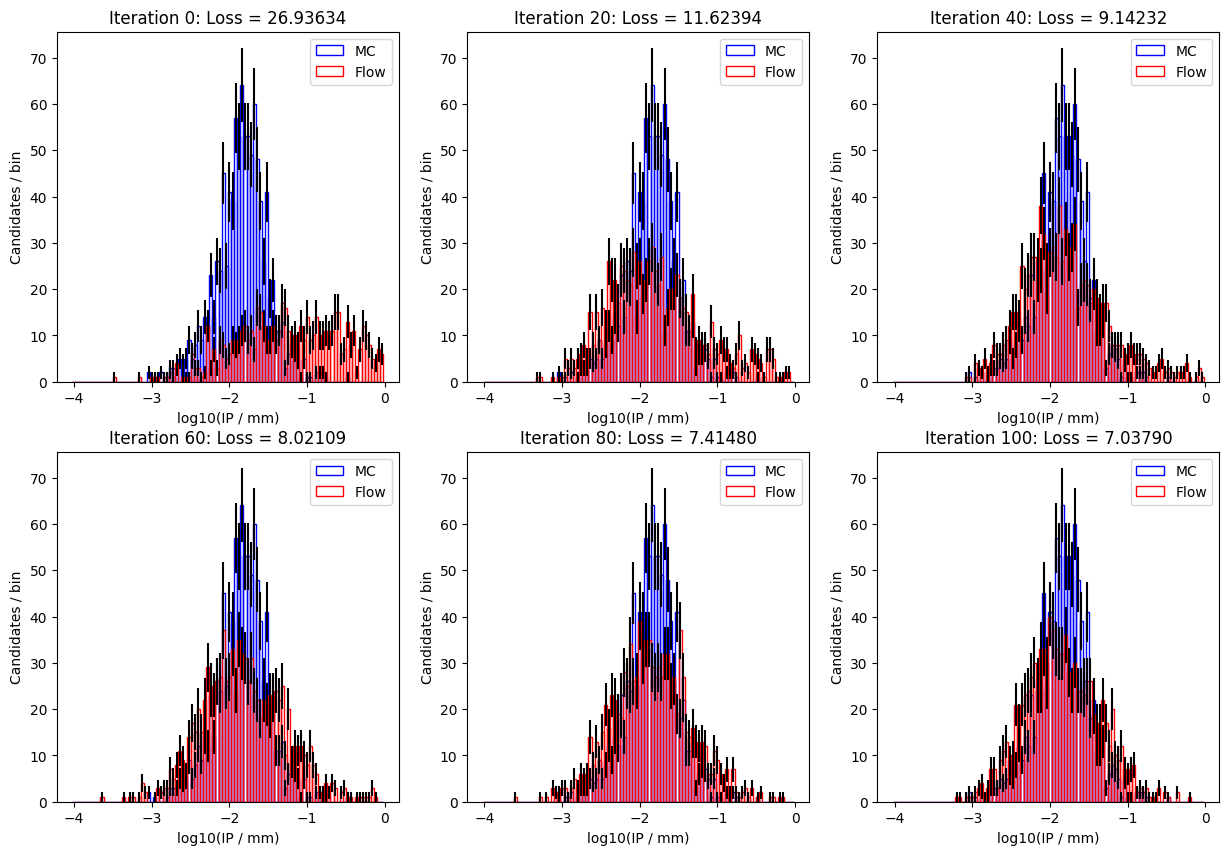

Execution time: 8.745089530944824 seconds
INFO:	Using device: cuda
Target data is on device: cuda:0
Loss at iteration 0: 1.7580609321594238
Loss at iteration 20: 1.5590240955352783
Loss at iteration 40: 1.3875436782836914
Loss at iteration 60: 1.2473963499069214
Loss at iteration 80: 1.137460708618164
Loss at iteration 100: 1.0535186529159546


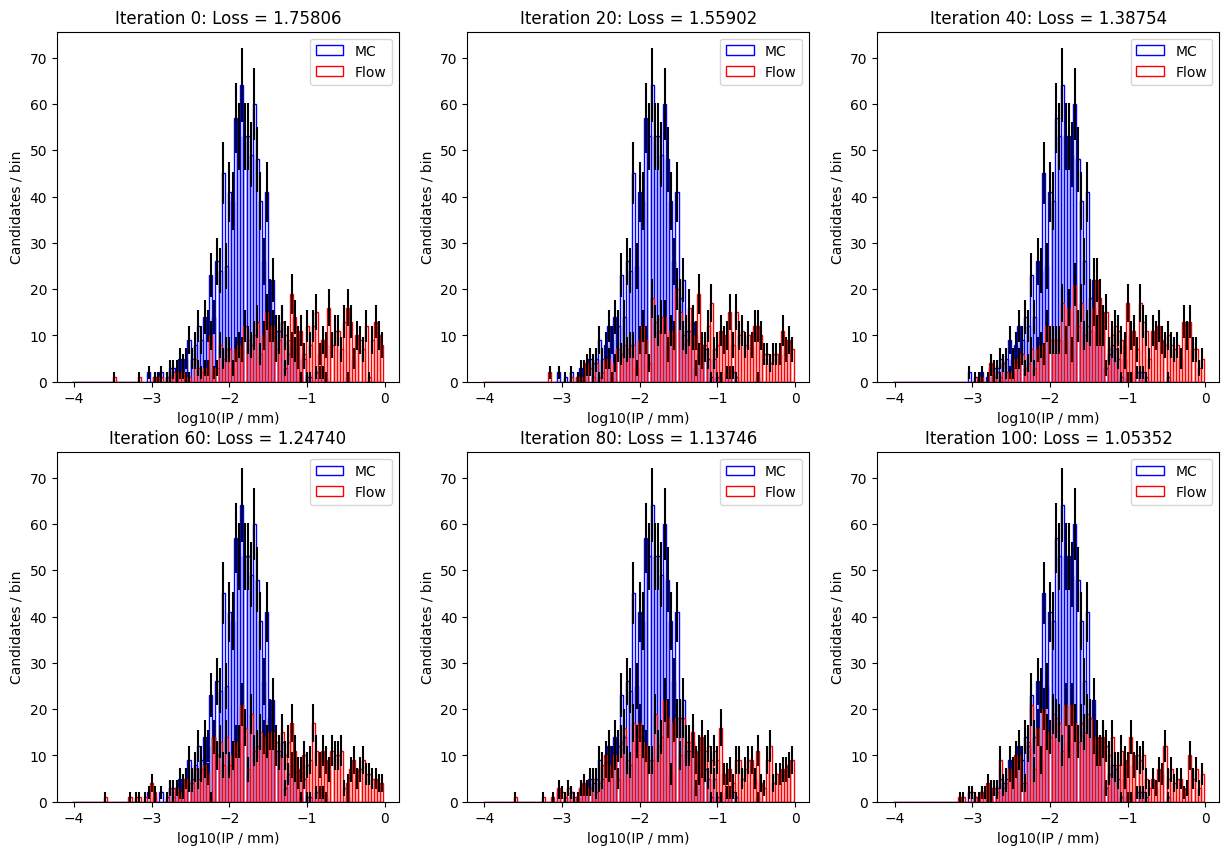

Execution time: 2.232710123062134 seconds


In [43]:
target_sample = load_data("Z", 1000)
for batch_the_data in (True, False):
    torch.manual_seed(42)
    start_time = time.time()
    quad_transform, quad_flow = make_1d_quad_flow()
    train_flow_hopefully_faster(quad_flow, target_sample, 100, use_gpu=True, batch_the_data=batch_the_data)
    end_time = time.time()

    execution_time = end_time - start_time
    print(f"Execution time: {execution_time} seconds")

OK, I played around a little bit, and I'm pretty convinced that everything is on the GPU and that it is just the batching that is slowing things down. Given I seem to be able to be faster with all my data in 1 batch, let's benchmark GPU vs CPU for that.

INFO:	Using device: cuda
Target data is on device: cuda:0
Loss at iteration 0: 1.7580609321594238
Loss at iteration 200: 0.8446248769760132
Loss at iteration 400: 0.6750602126121521
Loss at iteration 600: 0.5837380886077881
Loss at iteration 800: 0.5286614298820496
Loss at iteration 1000: 0.4930501878261566


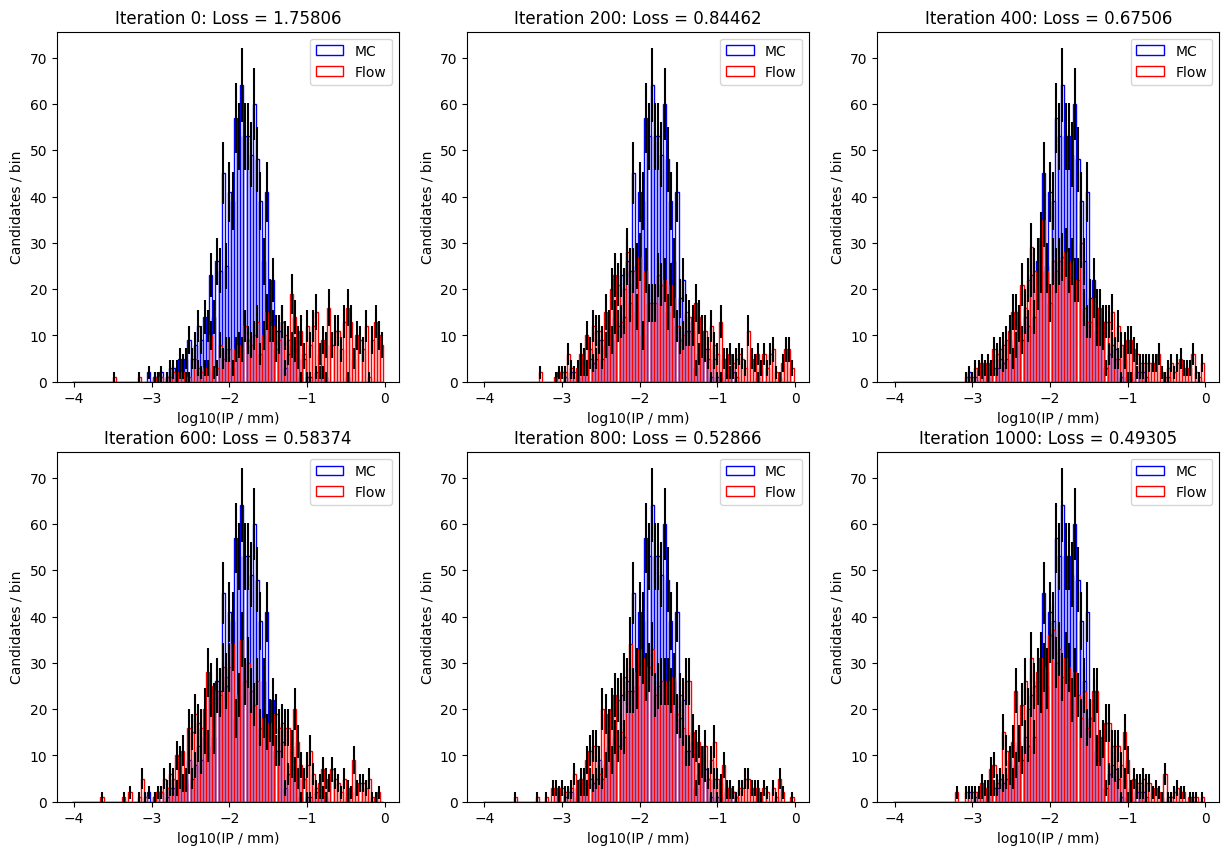

Execution time: 5.829437971115112 seconds
INFO:	Using device: cpu
Target data is on device: cpu
Loss at iteration 0: 1.7580608129501343
Loss at iteration 200: 0.8446247577667236
Loss at iteration 400: 0.675059974193573
Loss at iteration 600: 0.5837379097938538
Loss at iteration 800: 0.5286612510681152
Loss at iteration 1000: 0.49305006861686707


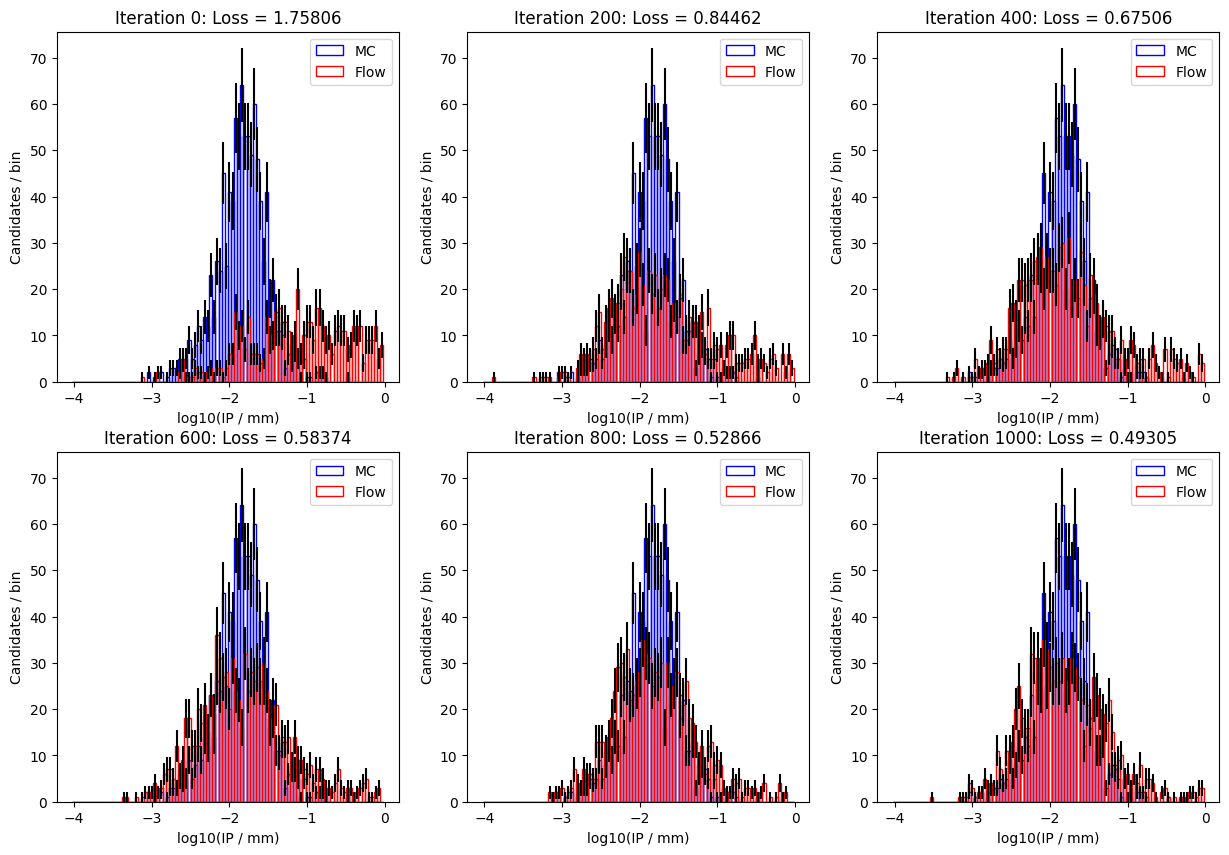

Execution time: 4.4656946659088135 seconds


In [44]:
target_sample = load_data("Z", 1000)
for use_gpu in (True, False):
    torch.manual_seed(42)
    start_time = time.time()
    quad_transform, quad_flow = make_1d_quad_flow()
    train_flow_hopefully_faster(quad_flow, target_sample, 1000, use_gpu=use_gpu, batch_the_data=False)
    end_time = time.time()

    execution_time = end_time - start_time
    print(f"Execution time: {execution_time} seconds")

OK, still a bit slower on the GPU. Can I speed up training then by moving the data closer to the unit Gaussian?

In [45]:
new_target_data = load_data("Z", 10000)
new_target_data + 2

tensor([[ 0.6073],
        [ 0.1144],
        [-0.2771],
        ...,
        [ 0.3098],
        [ 0.9335],
        [ 0.3873]])

INFO:	Using device: cuda
Target data is on device: cuda:0
Loss at iteration 0: 1.632651686668396
Loss at iteration 200: 0.9302701950073242
Loss at iteration 400: 0.518688440322876
Loss at iteration 600: 0.36604639887809753
Loss at iteration 800: 0.3351512551307678
Loss at iteration 1000: 0.3273710012435913


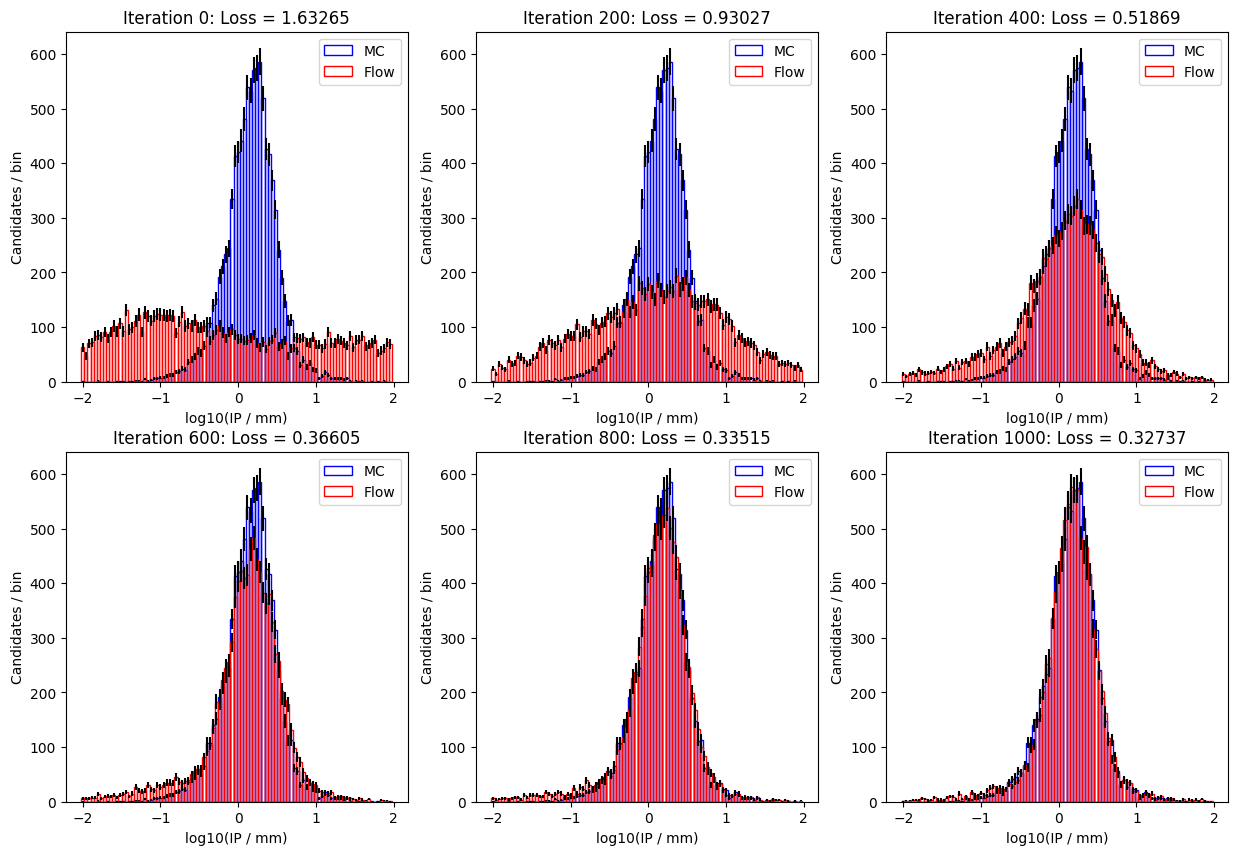

Execution time: 6.479642152786255 seconds
INFO:	Using device: cpu
Target data is on device: cpu
Loss at iteration 0: 1.6326518058776855
Loss at iteration 200: 0.930269718170166
Loss at iteration 400: 0.518688440322876
Loss at iteration 600: 0.3660464584827423
Loss at iteration 800: 0.3351512551307678
Loss at iteration 1000: 0.3273710012435913


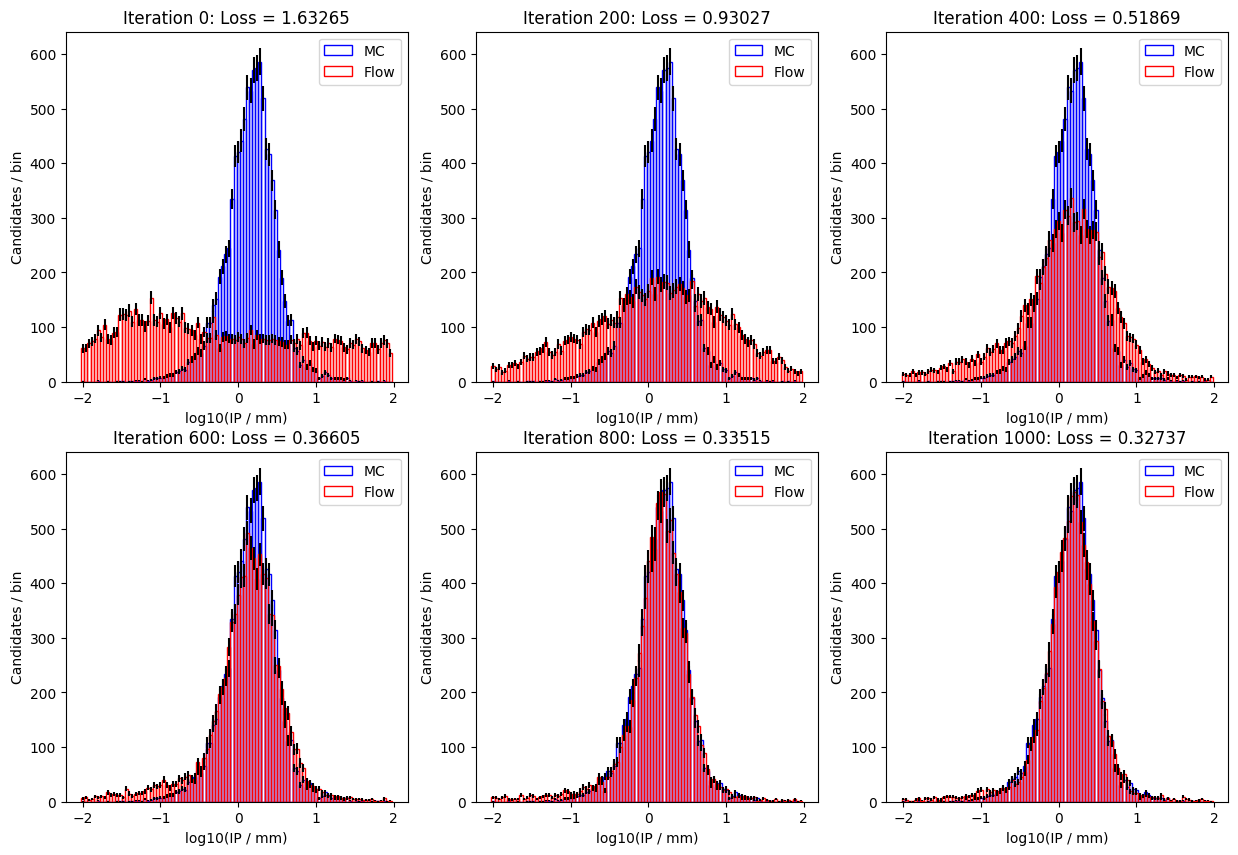

Execution time: 6.5002601146698 seconds


In [48]:
new_target_data += 2
for use_gpu in (True, False):
    torch.manual_seed(42)
    start_time = time.time()
    quad_transform, quad_flow = make_1d_quad_flow()
    train_flow_hopefully_faster(quad_flow, new_target_data, 1000, xrange=(-2, 2), use_gpu=use_gpu, batch_the_data=False)
    end_time = time.time()

    execution_time = end_time - start_time
    print(f"Execution time: {execution_time} seconds")

That does seem to help indeed, and notice that for 10k events here my CPU and GPU times are the same, and only 1000 iterations is doing quite well.

Let's just gently extend this to see if GPU starts to take over

INFO:	Using device: cuda
Target data is on device: cuda:0
Loss at iteration 0: 1.6333121061325073
Loss at iteration 200: 0.9272599220275879
Loss at iteration 400: 0.5108163356781006
Loss at iteration 600: 0.3550986647605896
Loss at iteration 800: 0.32347866892814636
Loss at iteration 1000: 0.3153529167175293


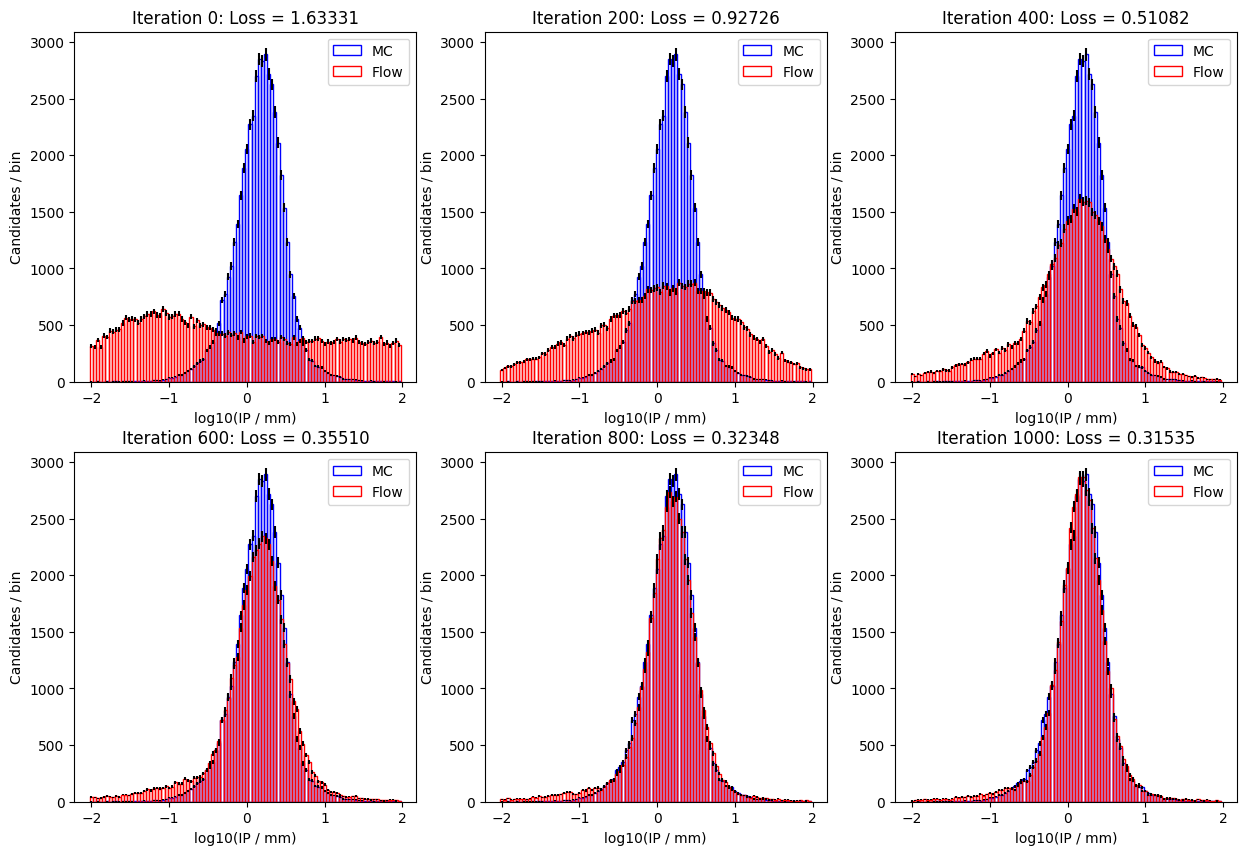

Execution time: 11.907448053359985 seconds
INFO:	Using device: cpu
Target data is on device: cpu
Loss at iteration 0: 1.6333122253417969
Loss at iteration 200: 0.9272598624229431
Loss at iteration 400: 0.5108165740966797
Loss at iteration 600: 0.35509878396987915
Loss at iteration 800: 0.3234787583351135
Loss at iteration 1000: 0.3153528571128845


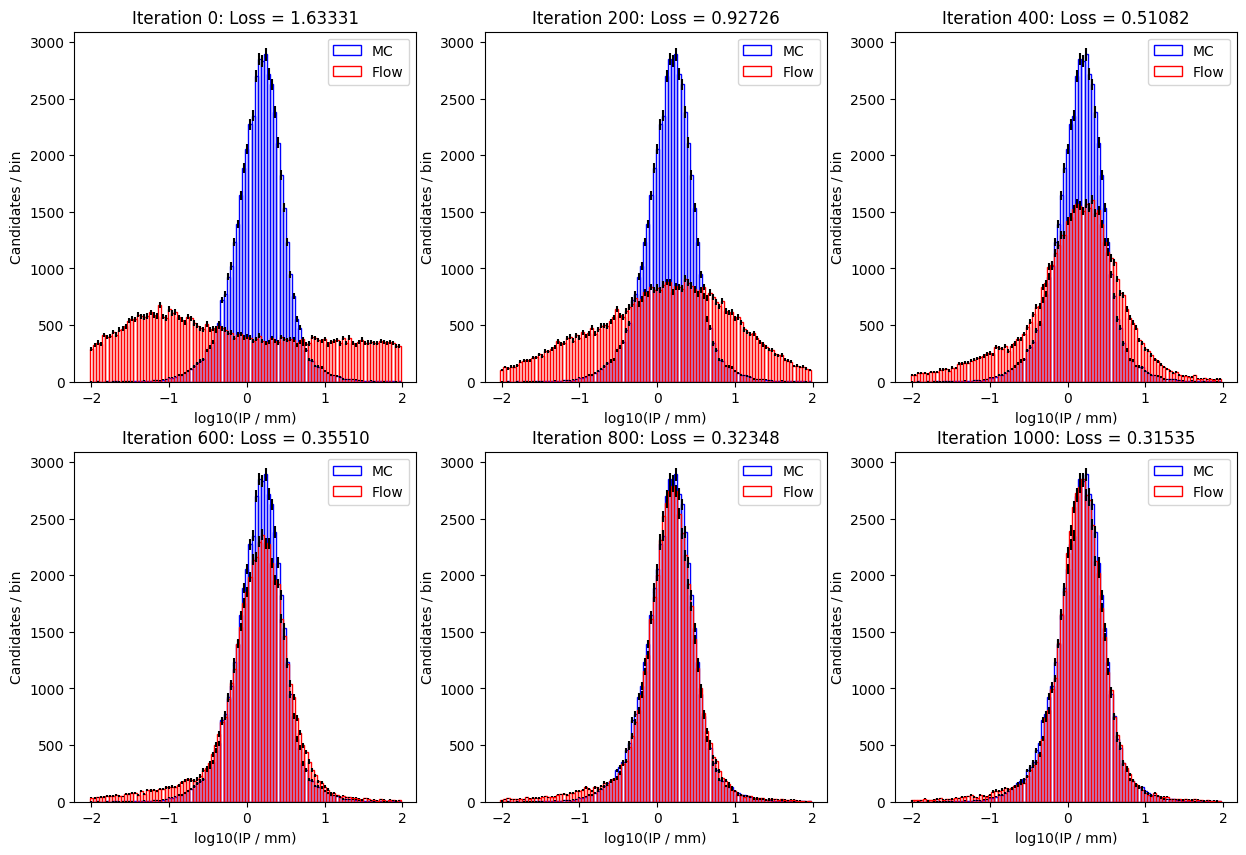

Execution time: 11.708673477172852 seconds


In [49]:
new_target_data = load_data("Z", 50000)
new_target_data += 2
for use_gpu in (True, False):
    torch.manual_seed(42)
    start_time = time.time()
    quad_transform, quad_flow = make_1d_quad_flow()
    train_flow_hopefully_faster(quad_flow, new_target_data, 1000, xrange=(-2, 2), use_gpu=use_gpu, batch_the_data=False)
    end_time = time.time()

    execution_time = end_time - start_time
    print(f"Execution time: {execution_time} seconds")

This is looking quite good. The flow looks basically trained after just 11s here. Not sure why it takes 5 mins usually.

We need to benchmark this a little more carefully: for example we can evaluate the chi2 and KS probability

Let's try here 100k candidates, and 2k iterations for now.

INFO:	Using device: cuda
Target data is on device: cuda:0
Loss at iteration 0: 1.6330252885818481
Loss at iteration 400: 0.5116479396820068
Loss at iteration 800: 0.32445642352104187
Loss at iteration 1200: 0.3122130036354065
Loss at iteration 1600: 0.30773472785949707
Loss at iteration 2000: 0.30544736981391907


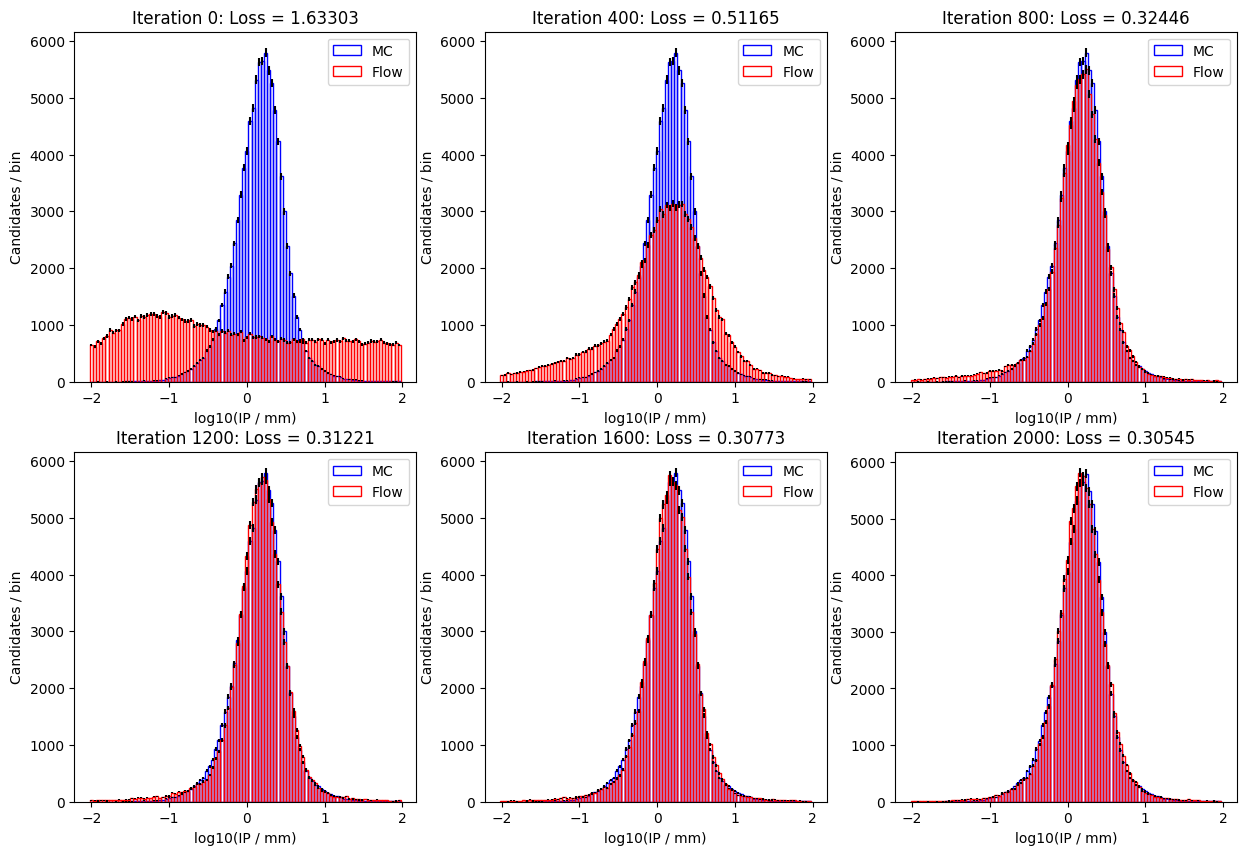

Execution time: 69.49384498596191 seconds
INFO:	Using device: cpu
Target data is on device: cpu
Loss at iteration 0: 1.6330252885818481
Loss at iteration 400: 0.5116478204727173
Loss at iteration 800: 0.32445645332336426
Loss at iteration 1200: 0.3122130334377289
Loss at iteration 1600: 0.30773475766181946
Loss at iteration 2000: 0.30544739961624146


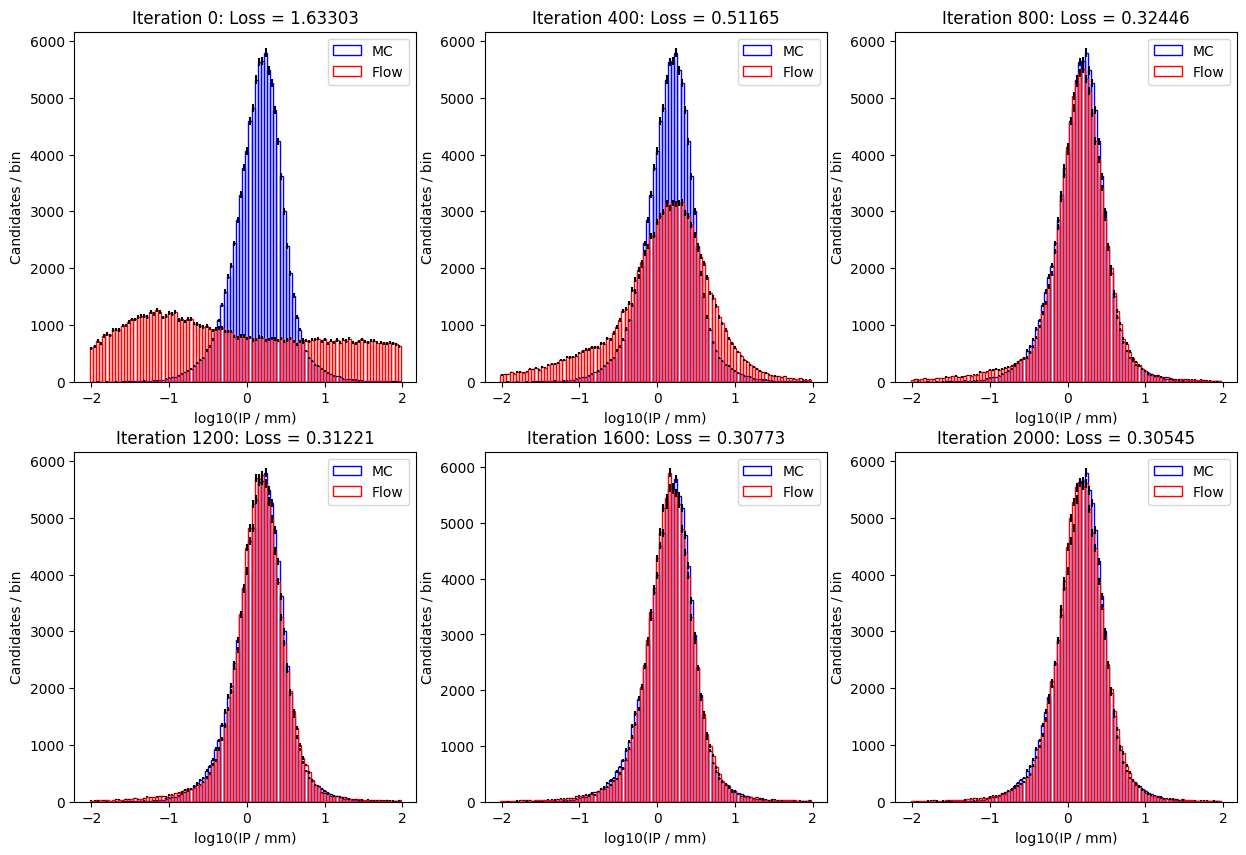

Execution time: 31.752774715423584 seconds


In [50]:
new_target_data = load_data("Z", 100000)
new_target_data += 2
for use_gpu in (True, False):
    torch.manual_seed(42)
    start_time = time.time()
    quad_transform, quad_flow = make_1d_quad_flow()
    train_flow_hopefully_faster(quad_flow, new_target_data, 2000, xrange=(-2, 2), use_gpu=use_gpu, batch_the_data=False)
    end_time = time.time()

    execution_time = end_time - start_time
    print(f"Execution time: {execution_time} seconds")


Thinking about it, probs I need more bins to get more of a transformation.

Interesting here I started to get a slow down for a GPU. I guess this means that my GPU memory is full at this point.